# The Royle-Nichols Model

As described in Royle and Dorazio [Hierarchical Modeling and Inference in Ecology](https://www.google.com/books/edition/Hierarchical_Modeling_and_Inference_in_E/rDppWpVP6a0C?hl=en&gbpv=1&bsq=royle-nichols%20model).

Suppose that $M$ sites are sampled $J$ times, with each sample indicating that a particular species was detected or not.

And suppose that the unknown population at each site is $N_i$ and the probability that each individual is detected is $r$. Assuming that the probabilities of detection are identical and independent, the probability that at least one individual is detected in any sample is

$$p_i = 1 - (1 - r)^{N_i}$$

In the case where $N_i = 0$, $p_i = 0$; if there are no individuals present, none will be detected.

Under these assumptions, the number of a times a species is detected at site $i$ is

$$y_i \sim \mathrm{Binomial}(J, p)$$

In addition, we assume that the distribution of $N_i$ across sites is Poisson with unknown parameter $\lambda$.

In [2]:
# install empiricaldist if necessary
try:
    import empiricaldist
except ImportError:
    !pip install empiricaldist

In [3]:
# Get utils.py

from os.path import basename, exists

def download(url):
    filename = basename(url)
    if not exists(filename):
        from urllib.request import urlretrieve
        local, _ = urlretrieve(url, filename)
        print('Downloaded ' + local)
    
download('https://github.com/AllenDowney/ThinkBayes2/raw/master/soln/utils.py')

In [4]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from utils import decorate

Here are prior distributions for $r$ and $\lambda$.

In [5]:
from utils import make_uniform

rs = np.linspace(0, 0.5, 51)
prior_r = make_uniform(rs, name='r')
prior_r.shape

(51,)

In [6]:
lams = np.linspace(0, 3, 61)
prior_lam = make_uniform(lams, name='lam')
prior_lam.shape

(61,)

And the joint distribution represented in a `DataFrame` and as a `Pmf`.

In [7]:
from utils import make_joint

joint_prior = make_joint(prior_r, prior_lam)
joint_prior.shape

(61, 51)

In [8]:
from empiricaldist import Pmf

joint_pmf = Pmf(joint_prior.stack())
joint_pmf.head(3)

lam  r   
0.0  0.00    0.000321
     0.01    0.000321
     0.02    0.000321
dtype: float64

As an example, we'll use catbird data from the North American Breeding Bird Survey (BBS) collected in 1991 along a route in New Hampshire.

In [9]:
from collections import Counter

detections = np.arange(12)
sites = np.array([31, 5, 5, 5, 2, 0, 1, 1, 0, 0, 0, 0])
unique_ys, = np.where(sites)
unique_ys

array([0, 1, 2, 3, 4, 6, 7])

In [10]:
pmf_y = Pmf(sites[unique_ys.astype(int)], unique_ys)
pmf_y

,probs
0,31
1,5
2,5
3,5
4,2
6,1
7,1


I'll expand the data into $y_i$ for the $M=50$ sites.

In [11]:
counter = Counter(dict(zip(detections, sites)))
ys = list(counter.elements())

As a starting place, suppose we are given $r$ and $\lambda$. The values here are the MLEs reported by Royle and Dorazio.

In [12]:
from scipy.stats import poisson

lam = 0.546
r = 0.179

To compute the likelihood of the data conditioned on these parameters, we have to sum over the possible values of $n$, weighted by the PMF of $n$. Here's the PMF of $n$.

In [13]:
ns = np.arange(70)
pmf_p = poisson.pmf(ns, lam)
pmf_p.shape

(70,)

And here's the joint distribution of $y$ and $n$.

In [14]:
from scipy.stats import binom
num_visits = 11

ps = 1 - (1-r)**ns
Y, P = np.meshgrid(ys, ps)
a = binom.pmf(Y, num_visits, P)
a.T.shape

(50, 70)

Now we have to weight the joint distribution with `pmf_p`

In [15]:
product = a.T * pmf_p
product.shape

(50, 70)

And sum across the possible values of $n$.

In [16]:
likes = product.sum(axis=1)
likes.shape

(50,)

The following figure shows the results so far.

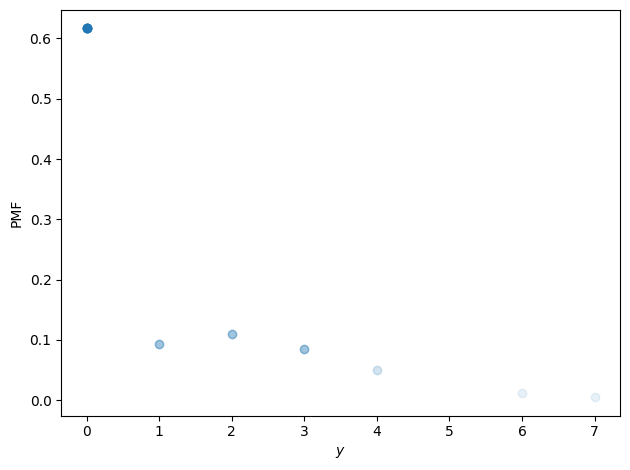

In [17]:
plt.plot(ys, likes, 'o', alpha=0.1)

decorate(xlabel='$y$', ylabel='PMF')

Finally, the likelihood (conditioned on $r$ and $\lambda$) is the product across the $y_i$.
The negative log likelihood is the same a reported by RD.

In [18]:
like = likes.prod()
-np.log(like)

65.97159119824022

Now we have what we need to compute the likelihood for each pair of parameters in the prior PMF:

In [19]:
ns = np.arange(70)
likelihood = joint_pmf.copy()

for lam, r in joint_pmf.index:
    ps = 1 - (1-r)**ns
    Y, P = np.meshgrid(ys, ps)
    a = binom.pmf(Y, num_visits, P)

    pmf_n = poisson.pmf(ns, lam)
    product = a.T * pmf_n
    likes = product.sum(axis=1)

    likelihood[lam, r] = likes.prod()

And here's the update.

In [20]:
posterior_pmf = joint_pmf * likelihood
posterior_pmf.normalize()

3.8597265954307577e-31

Here's what the joint posterior and marginals look like.

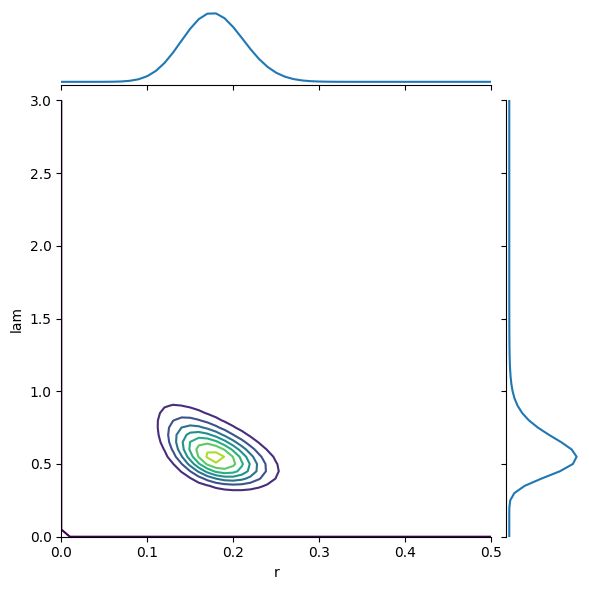

In [21]:
from utils import joint_plot

joint_posterior = posterior_pmf.unstack()
joint_plot(joint_posterior)

And here are the marginals with summary stats.

(0.5944391462050416, array([0.4 , 0.85]))

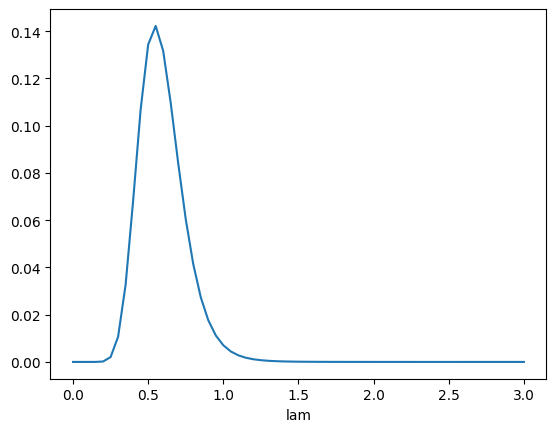

In [22]:
posterior_lam = posterior_pmf.marginal(0)
posterior_lam.plot()
posterior_lam.mean(), posterior_lam.credible_interval(0.9)

(0.17771703941586983, array([0.12, 0.24]))

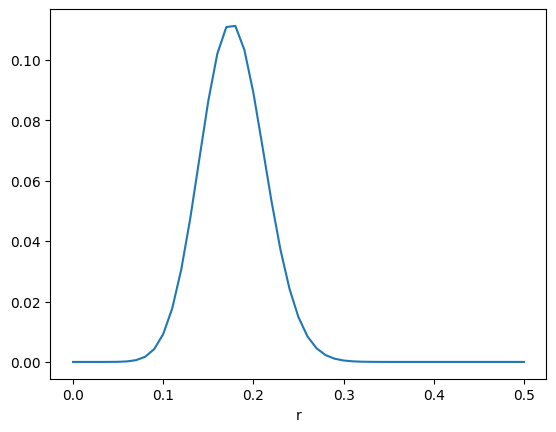

In [23]:
posterior_r = posterior_pmf.marginal(1)
posterior_r.plot()
posterior_r.mean(), posterior_r.credible_interval(0.9)

The MLEs for the parameters are consistent with the ones reported by RD, within the precision of the grid.

In [24]:
posterior_lam.idxmax(), posterior_r.idxmax()

(0.55, 0.18)

## Posterior conditional distribution of n

Given the posterior distribution, we can get the posterior distribution on $n$ conditioned on $y_i$. As an example, consider a site where $y_i=4$.

First, with given values of the parameters near the MLEs.

In [25]:
y = 4
lam = lams[11]
r = rs[18]
r, lam

(0.18, 0.55)

We can compute the conditional posterior distribution of $n$ by computing the joint distribution of $y_i$ and $p.$

In [26]:
ps = 1 - (1-r)**ns
y_range = np.arange(num_visits+1)
Y, P = np.meshgrid(y_range, ps)
a = binom.pmf(Y, num_visits, P)
a.shape

(70, 12)

And selecting the conditional distribution of $p$ given $y_i$.
Then, since $n$ is a function of $p$, we can transform the distribution of $p$ to the distribution of $n$ just by replacing the `ps` with the corresponding `ns`.

In [27]:
conditional_n = Pmf(a.T[y], ns)
conditional_n.normalize()

0.7219366998585915

In [28]:
conditional_n

,probs
0,0.000000e+00
1,1.196195e-01
2,3.271782e-01
3,2.868578e-01
4,1.590519e-01
...,...
65,2.788132e-37
66,6.950420e-38
67,1.732641e-38
68,4.319228e-39


2.863532503307563

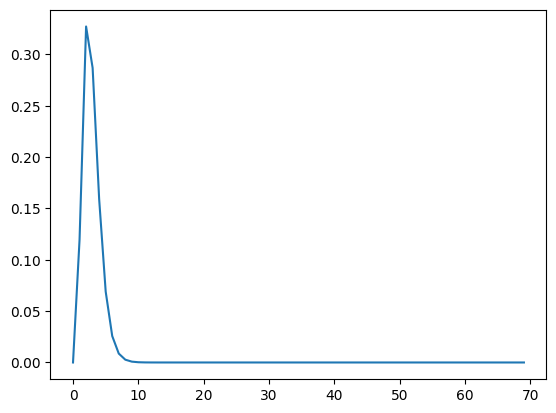

In [29]:
conditional_n.plot()
conditional_n.mean()

But all of that was based on given values of the parameters. To get the correct posterior conditional distribution, we have to integrate the computation we just did over the posterior distribution of the parameters.

In [30]:
pmf_seq = []

for lam, r in posterior_pmf.index:
    ps = 1 - (1-r)**ns
    Y, P = np.meshgrid(y_range, ps)
    a = binom.pmf(Y, num_visits, P)
    conditional = Pmf(a.T[y], ns)
    conditional.normalize()
    pmf_seq.append(conditional)

Here's what the result looks like compared to the approximation based on the MLE parameters.

In [31]:
from utils import make_mixture

conditional_y.plot(color='gray')
posterior_n_given_y = make_mixture(posterior_pmf, pmf_seq)
posterior_n_given_y.plot()
posterior_n_given_y.mean()

NameError: name 'conditional_y' is not defined

## Let's go PyMC

Here's a PyMC model that should be equivalent to the previous model.

The prior on `lam` is a gamma distribution rather than uniform, which might bias the estimates a little lower -- but that's not what I'm currently getting.

In [32]:
num_visits = 11

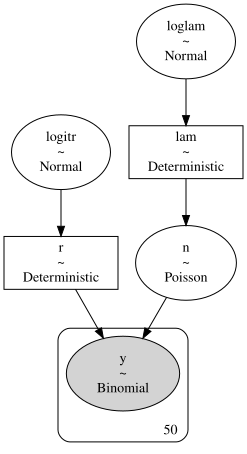

In [33]:
import pymc as pm

with pm.Model() as model:
    logitr = pm.Normal('logitr', mu=0, sigma=1.5)
    expr = pm.math.exp(logitr)
    r = pm.Deterministic('r', expr / (1 + expr))
    
    loglam = pm.Normal('loglam', mu=0, sigma=1)
    lam = pm.Deterministic('lam', pm.math.exp(loglam))
    n = pm.Poisson('n', mu=lam)
    p = 1 - (1-r)**n
    y = pm.Binomial('y', n=num_visits, p=p, observed=ys)

pm.model_to_graphviz(model)

In [34]:
with model:
    idata = pm.sample_prior_predictive(1000)

Sampling: [logitr, loglam, n, y]


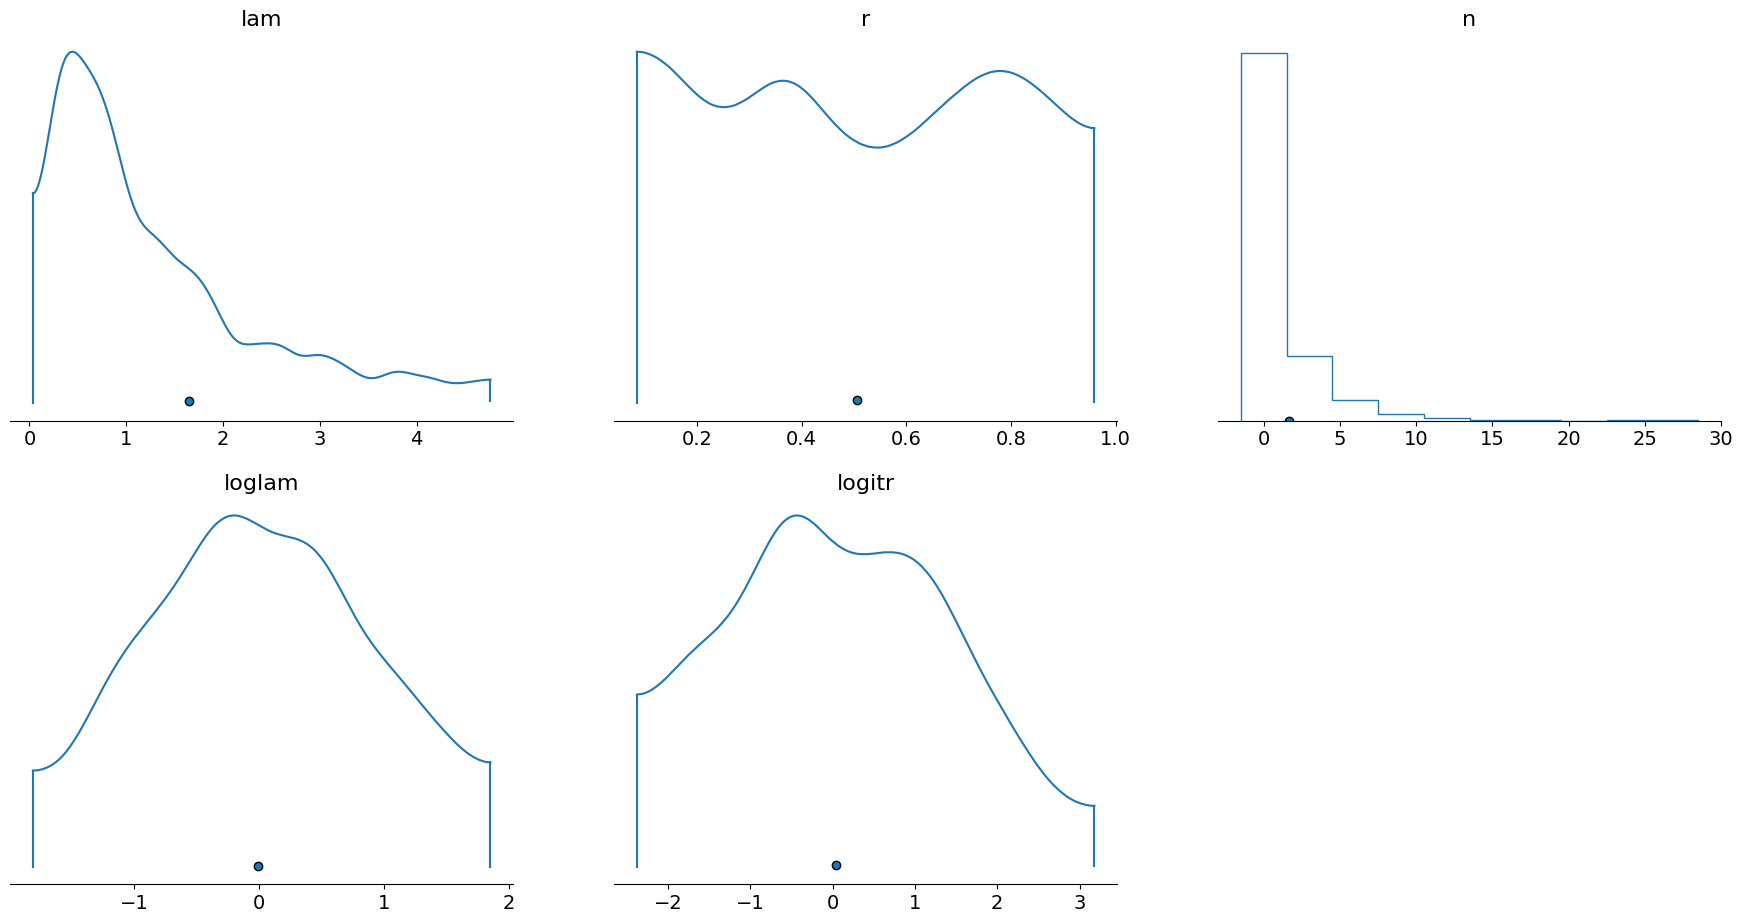

In [35]:
import arviz as az

az.plot_density(idata, 'prior')
None

The model samples ok, although it requires some tweaking to the sampler parameters.

In [36]:
with model:
    idata = pm.sample(1000,
                      tune=2000, 
                      nuts={'target_accept':0.97})

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>NUTS: [logitr, loglam]
>Metropolis: [n]


Sampling 4 chains for 2_000 tune and 1_000 draw iterations (8_000 + 4_000 draws total) took 4 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [38]:
import arviz as az

az.summary(idata)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
logitr,-2.520,0.453,-3.456,-1.981,0.174,0.129,10.0,21.0,1.36
loglam,0.070,0.753,-1.328,1.472,0.132,0.094,31.0,60.0,1.09
n,1.432,0.845,1.000,3.000,0.316,0.233,6.0,6.0,1.76
r,0.080,0.026,0.028,0.118,0.010,0.007,10.0,21.0,1.34
lam,1.399,1.077,0.115,3.317,0.212,0.152,31.0,60.0,1.09


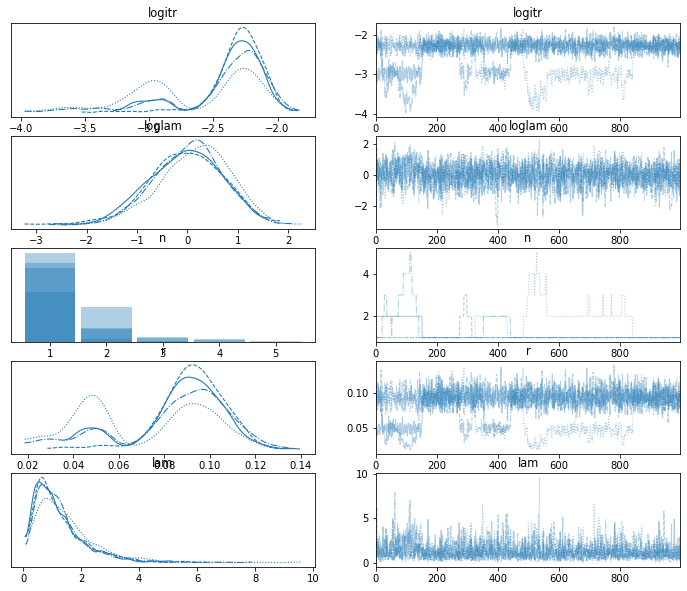

In [62]:

with model:
    az.plot_trace(idata)

The trace of `n` is a bit of a mess, and `r` should not be bimodal.
The posterior means are substantially different from what we got from the grid model.

In [63]:
az.summary(idata)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
logitr,-2.444,0.380,-3.194,-1.963,0.099,0.072,24.0,44.0,1.11
loglam,0.022,0.717,-1.309,1.300,0.039,0.028,320.0,809.0,1.02
n,1.274,0.596,1.000,2.000,0.157,0.113,13.0,13.0,1.23
r,0.084,0.024,0.037,0.120,0.006,0.004,24.0,44.0,1.11
lam,1.297,0.929,0.117,2.994,0.053,0.038,320.0,809.0,1.02


## Model 2

The previous model is simple enough for a grid algorithm, but a little nonsensical in the sense that $n$ does not vary between sites.
The following model estimates a different value of $n$ for each site.

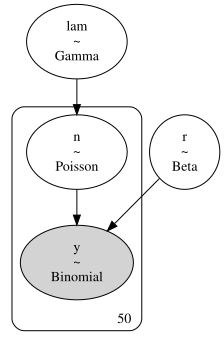

In [39]:
import pymc as pm

with pm.Model() as model2:
    r = pm.Beta('r', alpha=1, beta=1)
    lam = pm.Gamma('lam', alpha=1, beta=1)
    n = pm.Poisson('n', mu=lam, shape=len(ys))
    p = 1 - (1-r)**n
    y = pm.Binomial('y', n=num_visits, p=p, observed=ys)

pm.model_to_graphviz(model2)

In [40]:
with model2:
    idata = pm.sample_prior_predictive(1000)

Sampling: [lam, n, r, y]


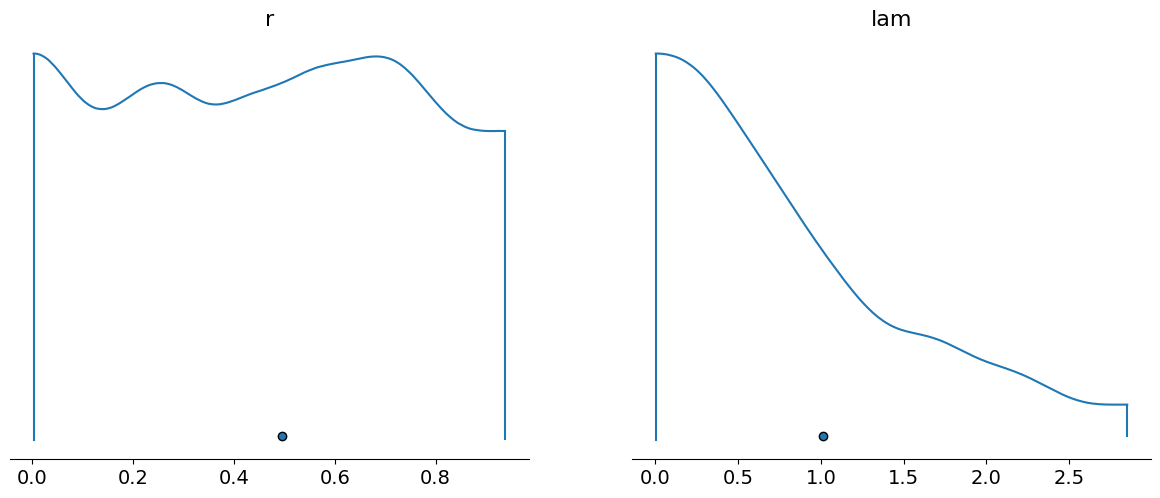

In [41]:
import arviz as az

az.plot_density(idata, 'prior', var_names=['r', 'lam'])
None

The model samples ok, although it's not happy about the acceptance probability.

In [46]:
with model2:
    idata = pm.sample(1000,
                      tune=4000, 
                      nuts={'target_accept':0.95})

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>NUTS: [r, lam]
>Metropolis: [n]


Sampling 4 chains for 4_000 tune and 1_000 draw iterations (16_000 + 4_000 draws total) took 15 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


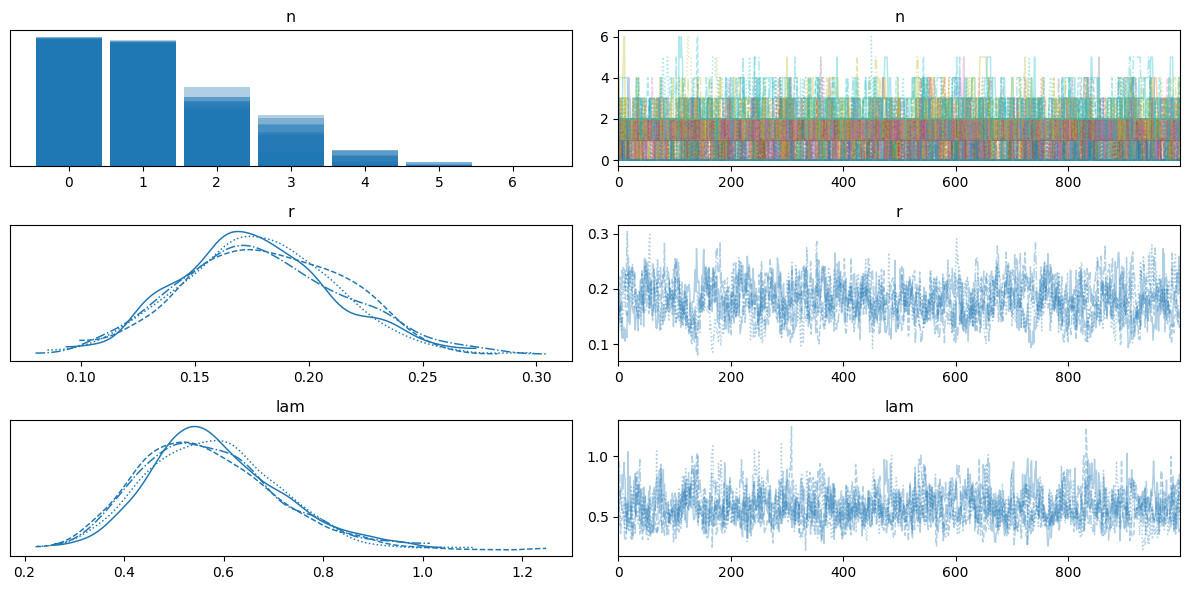

In [47]:
import arviz as az

with model2:
    az.plot_trace(idata)
    
plt.tight_layout()

In [48]:
az.summary(idata)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
n[0],0.065,0.250,0.000,1.000,0.009,0.007,698.0,706.0,1.01
n[1],0.072,0.267,0.000,1.000,0.011,0.008,568.0,574.0,1.01
n[2],0.096,0.317,0.000,1.000,0.015,0.010,460.0,457.0,1.00
n[3],0.070,0.267,0.000,1.000,0.011,0.008,594.0,623.0,1.00
n[4],0.087,0.309,0.000,1.000,0.014,0.010,486.0,512.0,1.01
n[5],0.088,0.293,0.000,1.000,0.013,0.009,491.0,510.0,1.00
n[6],0.049,0.215,0.000,0.000,0.009,0.007,522.0,522.0,1.02
n[7],0.081,0.284,0.000,1.000,0.011,0.008,628.0,628.0,1.01
n[8],0.068,0.284,0.000,1.000,0.012,0.009,635.0,687.0,1.00
n[9],0.074,0.269,0.000,1.000,0.011,0.008,593.0,588.0,1.01
